In [1]:
# Cell 2 — Imports
import cv2
import random
import numpy as np
import torch
import torch.nn.functional as F
import kornia
import kornia.augmentation as K
import matplotlib.pyplot as plt
from pathlib import Path
from ultralytics import YOLO

import sys
sys.path.append("..")

from video_segmentation import get_single_mask_from_image, overlay_patch_on_image

In [2]:
# Cell 3 — Config
# ── Training ──────────────────────────────────────────
PATCH_H          = 75
PATCH_W          = 50
PATCH_SCALE      = 0.5
SHIRT_TOP        = 0.20
SHIRT_BOT        = 0.48
EPSILON          = 1.0
LR               = 0.005
NUM_STEPS        = 1600
EOT_N            = 1
TOP_K            = 20     # coarse anchor top-K
FINE_TOP_K       = 40     # fine anchor top-K (stride-8 grid is 3x denser)

# ── Loss weights ──────────────────────────────────────
DISTORTION_LOSS_W  = 1
AREA_LOSS_W      = 0.0
LEG_START      = 0.7   # top of leg emphasis (0.0 = whole body, 0.7 = knees down)
LEG_WEIGHT     = 5.0

# ── Curriculum / blended training ─────────────────────
CURRICULUM_STEPS = 50
BLEND_EVAL_PROB  = 0.4

# ── Dataset ────────────────────────────────────────────
# Set USE_CACHED_SAMPLES=True if training_samples_v13.pkl already exists,
# or False to re-extract frames and masks from videos.
USE_CACHED_SAMPLES = True
MIN_MASK_PIXELS = 500

# ── Paths ──────────────────────────────────────────────
IMAGE_PATH       = f'C:/Projects/gaitkeeper/data_processed/test_videos_2/person.jpg'
VIDEO_DIR        = 'C:/Projects/gaitkeeper/data_processed/test_videos_2/subset'
FRAMES_PER_VIDEO = 50
# V13: cache file now stores per-frame masks — use a fresh filename so
# old V12 caches (which lack masks) are not accidentally reused.
SAMPLES_PATH     = f'training_samples_v13.pkl'

# ── Model ──────────────────────────────────────────────
YOLO_MODEL = 'yolov8n-seg'
DEVICE     = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {DEVICE}')


Using device: cuda


In [3]:
# Cell 4 — Load YOLOv8-seg, freeze weights
yolo = YOLO(YOLO_MODEL)
torch_model = yolo.model.to(DEVICE)
torch_model.eval()

for p in torch_model.parameters():
    p.requires_grad_(False)

print(f'Model loaded: {YOLO_MODEL} | Parameters frozen: {sum(p.numel() for p in torch_model.parameters()):,}')

Model loaded: yolov8n-seg | Parameters frozen: 3,409,968


In [4]:
# Load segmentation mask for the *evaluation* image (person.jpg).
# This mask is only used for the eval-image baseline — training now uses
# per-frame masks stored in training_samples (see Cell 9).
eval_image_mask = get_single_mask_from_image(IMAGE_PATH)


c:\Users\bdsoc\miniconda3\envs\gaitkeeper\lib\site-packages\huggingface_hub\file_download.py:945: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
c:\Users\bdsoc\miniconda3\envs\gaitkeeper\lib\site-packages\transformers\models\segformer\image_processing_segformer.py:103: FutureWarning: The `reduce_labels` parameter is deprecated and will be removed in a future version. Please use `do_reduce_labels` instead.
  warnings.warn(


In [5]:
# Cell 5 — Forward pass helpers
def yolo_raw_forward(img_tensor):
    with torch.enable_grad():
        torch_model.model[-1].shape = None
        out = torch_model(img_tensor)
    return {'preds': out[0][0], 'proto': out[0][1]}
    
def img_to_tensor(img_np):
    img = cv2.resize(img_np, (640, 640))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    t = torch.from_numpy(img.copy()).permute(2, 0, 1).float() / 255.0
    return t.unsqueeze(0).to(DEVICE)

In [6]:
# Cell 6 — Shirt detection and patch placement
def detect_shirt_region(img_np):
    """
    Returns (shirt_box_img, shirt_box_mask) in 640x640 and 160x160 coords.
    Returns (None, None) if no person detected.
    """
    with torch.no_grad():
        results = yolo(cv2.resize(img_np, (640, 640)), verbose=False)

    if not results or results[0].boxes is None or len(results[0].boxes) == 0:
        return None, None

    boxes = results[0].boxes
    person_mask = (boxes.cls == 0)
    if not person_mask.any():
        return None, None

    best_idx = boxes.conf[person_mask].argmax()
    x1, y1, x2, y2 = boxes.xyxy[person_mask][best_idx].cpu().numpy()

    h, w = y2 - y1, x2 - x1
    cx = (x1 + x2) / 2
    half_w = w * PATCH_SCALE / 2
    sx1 = int(cx - half_w)
    sy1 = int(y1 + h * SHIRT_TOP)
    sx2 = int(cx + half_w)
    sy2 = int(y1 + h * SHIRT_BOT)

    scale = 160 / 640
    mx1 = max(0, int(sx1 * scale))
    my1 = max(0, int(sy1 * scale))
    mx2 = min(159, int(sx2 * scale))
    my2 = min(159, int(sy2 * scale))

    if mx2 <= mx1 or my2 <= my1:
        return None, None

    return (sx1, sy1, sx2, sy2), (mx1, my1, mx2, my2)


def paste_patch(img_tensor, patch, shirt_box, frame_mask):
    """
    Paste patch onto img_tensor using frame_mask for pixel-accurate placement.

    V13 change: frame_mask is now passed explicitly (instead of relying on the
    global image_mask).  Each training sample carries its own mask, so the
    patch is placed correctly on every frame rather than always using the
    person.jpg mask.

    Args:
        img_tensor  : [1, 3, H, W] float32 tensor on DEVICE
        patch       : [1, 3, Ph, Pw] float32 tensor (requires_grad)
        shirt_box   : (x1, y1, x2, y2) in 640-px coords (unused — kept for
                      API compatibility; bounding box is derived from mask)
        frame_mask  : 2-D bool/uint8 tensor (H x W) for this specific frame
    """

    if frame_mask is None:
        # no mask — fall back to box-based placement to keep graph alive
        x1, y1, x2, y2 = [int(v) for v in shirt_box]
        w, h = x2 - x1, y2 - y1
        if w <= 0 or h <= 0:
            return img_tensor + patch.mean() * 0.0  # keeps grad_fn
        patch_resized = F.interpolate(patch, size=(h, w), mode='bilinear', align_corners=False)
        patched = img_tensor.clone()
        patched[:, :, y1:y2, x1:x2] = patch_resized
        return patched

    _, _, H, W = img_tensor.shape

    # handle both numpy arrays and tensors
    if isinstance(frame_mask, torch.Tensor):
        mask_np = frame_mask.cpu().numpy().astype(np.uint8)
    else:
        mask_np = frame_mask.astype(np.uint8)

    mask_resized = torch.tensor(
        cv2.resize(mask_np, (W, H), interpolation=cv2.INTER_NEAREST)
    ).bool().to(img_tensor.device)

    rows = mask_resized.any(dim=1)
    cols = mask_resized.any(dim=0)

    if not rows.any() or not cols.any():
        return img_tensor  # mask empty — nothing to paste

    y1, y2 = torch.where(rows)[0][[0, -1]].tolist()
    x1, x2 = torch.where(cols)[0][[0, -1]].tolist()
    bw, bh = x2 - x1, y2 - y1

    if bw <= 0 or bh <= 0:
        return img_tensor

    patch_box = F.interpolate(patch, size=(bh, bw), mode='bilinear', align_corners=False)
    mask_box  = mask_resized[y1:y2, x1:x2].unsqueeze(0).unsqueeze(0)

    patched = img_tensor.clone()
    patched[:, :, y1:y2, x1:x2] = torch.where(
        mask_box, patch_box, img_tensor[:, :, y1:y2, x1:x2]
    )
    return patched


In [7]:
def build_anchor_grid():
    strides, grids = [8, 16, 32], [80, 40, 20]
    cx_list, cy_list, stride_list = [], [], []
    for stride, g in zip(strides, grids):
        xs = (torch.arange(g, device=DEVICE) + 0.5) * stride
        ys = (torch.arange(g, device=DEVICE) + 0.5) * stride
        yy, xx = torch.meshgrid(ys, xs, indexing='ij')
        cx_list.append(xx.reshape(-1))
        cy_list.append(yy.reshape(-1))
        stride_list.append(torch.full((g * g,), stride, device=DEVICE))
    return torch.cat(cx_list), torch.cat(cy_list), torch.cat(stride_list)

ANCHOR_CX, ANCHOR_CY, ANCHOR_STRIDE = build_anchor_grid()
COARSE_MASK = (ANCHOR_STRIDE >= 16)   # 2000 anchors -- stride 16 + 32
FINE_MASK   = (ANCHOR_STRIDE == 8)    # 6400 anchors -- stride 8

def get_mask_prob(raw):
    """Extract predicted segmentation mask as a 160x160 probability map."""
    preds = raw['preds']
    proto = raw['proto']
    person_conf = torch.sigmoid(preds[0, 4, :])
    best = person_conf.argmax()
    mask_coeff  = preds[0, 84:, best]
    proto_flat  = proto[0].reshape(32, -1)
    mask_logits = (mask_coeff @ proto_flat).reshape(160, 160)
    return torch.sigmoid(mask_logits)

def build_leg_weight_map(height=160, width=160, leg_start=0.5, leg_weight=3.0):
    """
    Returns a [160, 160] weight map that ramps up toward the bottom.
    
    leg_start  : fraction down the mask where leg emphasis begins (0.5 = halfway)
    leg_weight : maximum weight at the bottom of the mask
    """
    # linear ramp from 1.0 at the top to leg_weight at the bottom
    ramp = torch.linspace(1.0, leg_weight, height, device=DEVICE)
    
    # flatten weights above leg_start — keep upper body at 1.0
    cutoff = int(height * leg_start)
    ramp[:cutoff] = 1.0
    
    return ramp.unsqueeze(1).expand(height, width)  # [160, 160]

LEG_WEIGHT_MAP = build_leg_weight_map(leg_start=LEG_START, leg_weight=LEG_WEIGHT)

def mask_distortion_loss(raw_clean, raw_patched):
    """Maximize weighted L1 difference, emphasising leg region."""
    clean_mask   = get_mask_prob(raw_clean).detach()
    patched_mask = get_mask_prob(raw_patched)
    diff = torch.abs(clean_mask - patched_mask) * LEG_WEIGHT_MAP
    return -diff.mean()

def mask_area_loss(raw):
    """Maximize predicted mask area, emphasising leg region."""
    mask_prob = get_mask_prob(raw)
    return -(mask_prob * LEG_WEIGHT_MAP).mean()

def combined_loss(raw_clean, raw_patched):
    d_loss = mask_distortion_loss(raw_clean, raw_patched)
    a_loss = mask_area_loss(raw_patched)
    return DISTORTION_LOSS_W * d_loss + AREA_LOSS_W * a_loss

In [8]:
# Cell 8 — Differentiable EoT transforms via kornia
def apply_eot_transforms(patch):
    """patch: [1, 3, H, W] — returns augmented patch, gradient preserved."""
    p = patch

    if random.random() < 0.5:
        p = (p * random.uniform(0.6, 1.4)).clamp(0, 1)

    if random.random() < 0.5:
        p = K.ColorJitter(hue=0.1, saturation=0.1, p=1.0)(p)

    if random.random() < 0.5:
        angle = torch.tensor([random.uniform(-15, 15)], device=DEVICE)
        p = kornia.geometry.rotate(p, angle)

    if random.random() < 0.5:
        p = K.RandomPerspective(distortion_scale=0.2, p=1.0)(p)

    if random.random() < 0.5:
        ksize = random.choice([3, 5, 7])
        p = kornia.filters.motion_blur(p, kernel_size=ksize,
                                       angle=random.uniform(0, 360), direction=0.0)

    if random.random() < 0.5:
        p = p + torch.randn_like(p) * random.uniform(0, 10) / 255.0

    if random.random() < 0.7:
        scale_factor = random.uniform(0.6, 1.4)
        new_h = max(1, int(p.shape[2] * scale_factor))
        new_w = max(1, int(p.shape[3] * scale_factor))
        p = F.interpolate(p, size=(new_h, new_w), mode='bilinear', align_corners=False)
        p = F.interpolate(p, size=(patch.shape[2], patch.shape[3]), mode='bilinear', align_corners=False)

    return p.clamp(0, 1)

In [9]:
# Cell 9 — Load or build training dataset
#
# V13 change: each sample is now a 4-tuple
#   (frame_np, box_img, box_mask, seg_mask)
# where seg_mask is the pixel-level segmentation mask for that specific frame.
# This lets paste_patch place the adversarial patch correctly on every frame
# rather than always reusing the person.jpg mask.
#
# If USE_CACHED_SAMPLES is True, the notebook tries to load SAMPLES_PATH.
# Make sure SAMPLES_PATH points to a V13 cache (4-tuples); V12 caches
# (3-tuples) will be detected and rebuilt automatically.

import pickle
from glob import glob

def _is_v13_cache(samples):
    """Return True if the loaded cache contains per-frame masks (V13 format)."""
    return len(samples) > 0 and len(samples[0]) == 4

if USE_CACHED_SAMPLES and Path(SAMPLES_PATH).exists():
    with open(SAMPLES_PATH, 'rb') as f:
        training_samples = pickle.load(f)
    if _is_v13_cache(training_samples):
        print(f'Loaded {len(training_samples)} V13 samples from {SAMPLES_PATH}')
    else:
        print(f'WARNING: {SAMPLES_PATH} contains V12 (3-tuple) samples — rebuilding.')
        USE_CACHED_SAMPLES = False  # fall through to rebuild

if not USE_CACHED_SAMPLES or not Path(SAMPLES_PATH).exists():
    def sample_frames_from_video(video_path, n_frames):
        cap = cv2.VideoCapture(video_path)
        total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        if total <= 0:
            cap.release()
            return []
        indices = [int(i * total / n_frames) for i in range(n_frames)]
        frames = []
        for idx in indices:
            cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
            ret, frame = cap.read()
            if ret:
                frames.append(frame)
        cap.release()
        return frames

    video_paths = glob(f'{VIDEO_DIR}/**/*.mp4', recursive=True)
    print(f'Found {len(video_paths)} videos. Extracting frames...')

    training_samples = []
    for vp in sorted(video_paths):
        frames = sample_frames_from_video(vp, FRAMES_PER_VIDEO)
        valid = 0
        for frame in frames:
            b_img, b_mask = detect_shirt_region(frame)
            if b_img is not None:
                frame_seg_mask = get_single_mask_from_image(frame)
                if frame_seg_mask is not None and frame_seg_mask.sum() > MIN_MASK_PIXELS:  # ← add this check
                    training_samples.append((frame, b_img, b_mask, frame_seg_mask))
                    valid += 1
        print(f'  {Path(vp).name}: {valid}/{len(frames)} frames detected')

    with open(SAMPLES_PATH, 'wb') as f:
        pickle.dump(training_samples, f)
    print(f'\nSaved {len(training_samples)} V13 samples to {SAMPLES_PATH}')

print(f'Total training samples: {len(training_samples)}')


Loaded 72 V13 samples from training_samples_v13.pkl
Total training samples: 72


In [10]:
# Cell 10 — Initialize patch + baseline
img_eval = cv2.imread(IMAGE_PATH)
if img_eval is None:
    raise FileNotFoundError(f'Could not load {IMAGE_PATH}')

with torch.no_grad():
    raw_baseline = yolo_raw_forward(img_to_tensor(img_eval))
    box_eval_img, box_eval_mask = detect_shirt_region(img_eval)
    baseline_conf = torch.sigmoid(raw_baseline['preds'][0, 4, :])[COARSE_MASK].topk(TOP_K).values.mean().item()

print(f'Baseline person conf in patch region: {baseline_conf:.4f}')

torch.manual_seed(42)
patch = torch.empty(1, 3, PATCH_H, PATCH_W, device=DEVICE).uniform_(0.4, 0.6)
patch.requires_grad_(True)
patch_init = patch.data.clone()

optimizer = torch.optim.Adam([patch], lr=LR)
print(f'Patch initialized: {list(patch.shape)}')


Baseline person conf in patch region: 0.5884
Patch initialized: [1, 3, 75, 50]


In [11]:
# Cell 11 — Training loop (V13: multi-frame with per-frame masks)
#
# V13 changes over V12:
#   - training_samples are now 4-tuples (frame, box_img, box_mask, seg_mask)
#   - paste_patch receives the per-frame seg_mask instead of the global
#     image_mask, so the patch is placed accurately on every training frame
#   - eval_sample uses eval_image_mask (derived from person.jpg) for the
#     curriculum phase — same behaviour as V12 for the anchor frame
#
# Phase 1 (0 → CURRICULUM_STEPS-1):  eval image only, LR=0.005
# Phase 2 (CURRICULUM_STEPS → 799):  blended 40% eval / 60% dataset, LR=0.002
# Phase 3 (800 → end):               blended, LR=0.0005

if not training_samples:
    raise RuntimeError('No training samples — run Cell 9 first')

# Build eval tuple — uses the eval image mask (person.jpg)
eval_sample = (img_eval, box_eval_img, box_eval_mask, eval_image_mask)

loss_history      = []
distort_history  = []
area_history      = []
phase_switch_step = None
phase3_step       = None

for step in range(NUM_STEPS):
    optimizer.zero_grad()

    if step < CURRICULUM_STEPS:
        img, box_img, box_mask, frame_mask = eval_sample
    else:
        if phase_switch_step is None:
            phase_switch_step = step
            print(f'Step {step}: phase 2 — blended training '
                  f'({BLEND_EVAL_PROB:.0%} eval / {1-BLEND_EVAL_PROB:.0%} dataset)')
            for g in optimizer.param_groups:
                g['lr'] = 0.002
            print('LR decayed to 0.002')

        if step >= 800 and phase3_step is None:
            phase3_step = step
            print(f'Step {step}: phase 3 — fine-tune')
            for g in optimizer.param_groups:
                g['lr'] = 0.0005
            print('LR decayed to 0.0005')

        if random.random() < BLEND_EVAL_PROB:
            img, box_img, box_mask, frame_mask = eval_sample
        else:
            img, box_img, box_mask, frame_mask = random.choice(training_samples)

    img_tensor = img_to_tensor(img)

    # clean forward pass once per step — no grad needed, just the reference mask
    with torch.no_grad():
        raw_clean = yolo_raw_forward(img_tensor)

    step_loss = 0.0
    step_distort = step_area = 0.0

    for _ in range(EOT_N):
        aug_patch = apply_eot_transforms(patch)
        patched   = paste_patch(img_tensor, aug_patch, box_img, frame_mask)
        raw       = yolo_raw_forward(patched)

        if not raw['preds'].requires_grad:
            continue

        d_loss = mask_distortion_loss(raw_clean, raw)
        a_loss = mask_area_loss(raw)
        loss   = combined_loss(raw_clean, raw) / EOT_N
        loss.backward()

        step_loss   += loss.item()
        step_distort += d_loss.item() / EOT_N
        step_area    += a_loss.item() / EOT_N

    optimizer.step()


    with torch.no_grad():
        delta = (patch - patch_init).clamp(-EPSILON, EPSILON)
        patch.copy_((patch_init + delta).clamp(0, 1))

    loss_history.append(step_loss)
    distort_history.append(step_distort)
    area_history.append(step_area)

    if step % 50 == 0:
        delta_stats = (patch.data - patch_init)
        if step < CURRICULUM_STEPS:
            phase = 'curriculum'
        elif phase3_step is None:
            phase = 'blended-p2'
        else:
            phase = 'blended-p3'
        print(f'Step {step:4d}/{NUM_STEPS} | loss {step_loss:.4f} '
            f'[distort {step_distort:.4f} | area {step_area:.4f}] '
            f'| Δpatch mean {delta_stats.mean().item():+.4f} max {delta_stats.abs().max().item():.4f} '
            f'| {phase}')

print('Training complete.')


Step    0/1600 | loss -0.0108 [distort -0.0108 | area -0.1648] | Δpatch mean +0.0001 max 0.0050 | curriculum
Step 50: phase 2 — blended training (40% eval / 60% dataset)
LR decayed to 0.002
Step   50/1600 | loss -0.0415 [distort -0.0415 | area -0.1674] | Δpatch mean +0.0002 max 0.1785 | blended-p2
Step  100/1600 | loss -0.0108 [distort -0.0108 | area -0.0495] | Δpatch mean -0.0003 max 0.2026 | blended-p2
Step  150/1600 | loss -0.0165 [distort -0.0165 | area -0.0995] | Δpatch mean -0.0005 max 0.2326 | blended-p2
Step  200/1600 | loss -0.0277 [distort -0.0277 | area -0.1719] | Δpatch mean -0.0007 max 0.2472 | blended-p2
Step  250/1600 | loss -0.0346 [distort -0.0346 | area -0.1715] | Δpatch mean -0.0009 max 0.2815 | blended-p2
Step  300/1600 | loss -0.0250 [distort -0.0250 | area -0.1738] | Δpatch mean -0.0011 max 0.2837 | blended-p2
Step  350/1600 | loss -0.0280 [distort -0.0280 | area -0.1506] | Δpatch mean -0.0013 max 0.3007 | blended-p2
Step  400/1600 | loss -0.0409 [distort -0.0409 

In [16]:
# Cell 12 — Evaluation metrics
img_eval        = cv2.imread(IMAGE_PATH)
img_eval_640    = cv2.resize(img_eval, (640, 640))
img_tensor_eval = img_to_tensor(img_eval)
box_eval_img, box_eval_mask = detect_shirt_region(img_eval)

patch_np = patch.detach().cpu().squeeze().permute(1, 2, 0).numpy()
patch_np = (patch_np * 255).astype(np.uint8)

img_patched_np = overlay_patch_on_image(img_eval_640, eval_image_mask, patch_np)

with torch.no_grad():
    raw_clean   = yolo_raw_forward(img_tensor_eval)
    # V13: pass eval_image_mask explicitly
    patched_t   = paste_patch(img_tensor_eval, patch, box_eval_img, eval_image_mask)
    raw_patched = yolo_raw_forward(patched_t)

    #clean_suppress   = person_suppress_loss(raw_clean).item()
    #patched_suppress = person_suppress_loss(raw_patched).item()
    #clean_mask       = mask_suppression_loss(raw_clean,   box_eval_mask).item()
    #patched_mask     = mask_suppression_loss(raw_patched, box_eval_mask).item()

    clean_all_conf   = torch.sigmoid(raw_clean['preds'][0, 4, :])
    patched_all_conf = torch.sigmoid(raw_patched['preds'][0, 4, :])

    # Coarse top-K
    clean_topk   = clean_all_conf[COARSE_MASK].topk(TOP_K).values
    patched_topk = patched_all_conf[COARSE_MASK].topk(TOP_K).values

    # Fine top-K
    clean_fine_topk   = clean_all_conf[FINE_MASK].topk(FINE_TOP_K).values
    patched_fine_topk = patched_all_conf[FINE_MASK].topk(FINE_TOP_K).values

results_clean_eval   = yolo(img_eval_640,   verbose=False)
results_patched_eval = yolo(img_patched_np, verbose=False)

def best_person_conf(results):
    boxes = results[0].boxes
    if boxes is None or len(boxes) == 0:
        return None
    m = (boxes.cls == 0)
    return boxes.conf[m].max().item() if m.any() else None

yolo_clean   = best_person_conf(results_clean_eval)
yolo_patched = best_person_conf(results_patched_eval)

def pct(a, b):
    return (a - (b or 0)) / (a + 1e-9) * 100

print('═' * 62)
print('  LOSS COMPONENTS')
print('─' * 62)
print(f'  {"Metric":<38} {"Clean":>7}  {"Patched":>8}')
print('─' * 62)
#print(f'  {"Person suppress (max-anchored)":<38} {clean_suppress:>7.4f}  {patched_suppress:>8.4f}')
#print(f'  {"Mask prob in patch region":<38} {clean_mask:>7.4f}  {patched_mask:>8.4f}  ({pct(clean_mask,patched_mask):+.1f}%)')

print()
print('  ANCHOR-LEVEL PERSON CONFIDENCE — COARSE (top-K)')
print('─' * 62)
print(f'  {"Top-K mean":<38} {clean_topk.mean().item():>7.4f}  {patched_topk.mean().item():>8.4f}  ({pct(clean_topk.mean().item(), patched_topk.mean().item()):+.1f}%)')
print(f'  {"Top-K max":<38} {clean_topk.max().item():>7.4f}  {patched_topk.max().item():>8.4f}  ({pct(clean_topk.max().item(), patched_topk.max().item()):+.1f}%)')
print(f'  {"Top-K min":<38} {clean_topk.min().item():>7.4f}  {patched_topk.min().item():>8.4f}  ({pct(clean_topk.min().item(), patched_topk.min().item()):+.1f}%)')

print()
print('  ANCHOR-LEVEL PERSON CONFIDENCE — FINE (top-K)')
print('─' * 62)
print(f'  {"Top-K mean":<38} {clean_fine_topk.mean().item():>7.4f}  {patched_fine_topk.mean().item():>8.4f}  ({pct(clean_fine_topk.mean().item(), patched_fine_topk.mean().item()):+.1f}%)')
print(f'  {"Top-K max":<38} {clean_fine_topk.max().item():>7.4f}  {patched_fine_topk.max().item():>8.4f}  ({pct(clean_fine_topk.max().item(), patched_fine_topk.max().item()):+.1f}%)')

print()
print(f'  {"Global max (all 8400)":<38} {clean_all_conf.max().item():>7.4f}  {patched_all_conf.max().item():>8.4f}  ({pct(clean_all_conf.max().item(), patched_all_conf.max().item()):+.1f}%)')
print(f'  {"Global mean (all 8400)":<38} {clean_all_conf.mean().item():>7.4f}  {patched_all_conf.mean().item():>8.4f}')

print()
print('  YOLO HIGH-LEVEL OUTPUT (post-NMS)')
print('─' * 62)
if yolo_clean is not None:
    patched_str = f'{yolo_patched:.4f}' if yolo_patched else 'NO DETECT'
    print(f'  {"Best person detection conf":<38} {yolo_clean:>7.4f}  {patched_str:>8}  ({pct(yolo_clean, yolo_patched):+.1f}%)')
print(f'  All detections (patched image):')
if results_patched_eval[0].boxes is not None:
    COCO_NAMES = yolo.names
    for cls_id, conf in zip(results_patched_eval[0].boxes.cls, results_patched_eval[0].boxes.conf):
        print(f'    {COCO_NAMES[int(cls_id)]:<20} conf={conf.item():.4f}')
else:
    print('    (none)')

print()
print('  PATCH STATISTICS')
print('─' * 62)
delta = (patch.data - patch_init)
print(f'  {"Δ mean":<38} {delta.mean().item():>+.4f}')
print(f'  {"Δ std":<38} {delta.std().item():>.4f}')
print(f'  {"Δ max abs":<38} {delta.abs().max().item():>.4f}  (EPSILON={EPSILON})')
print(f'  {"% pixels at epsilon boundary":<38} {((delta.abs() > EPSILON*0.99).float().mean().item()*100):>.1f}%')
print(f'  {"Patch pixel mean":<38} {patch.data.mean().item():>.4f}')
print(f'  {"Patch pixel std":<38} {patch.data.std().item():>.4f}')
print('═' * 62)


══════════════════════════════════════════════════════════════
  LOSS COMPONENTS
──────────────────────────────────────────────────────────────
  Metric                                   Clean   Patched
──────────────────────────────────────────────────────────────

  ANCHOR-LEVEL PERSON CONFIDENCE — COARSE (top-K)
──────────────────────────────────────────────────────────────
  Top-K mean                              0.5884    0.5712  (+2.9%)
  Top-K max                               0.7041    0.6514  (+7.5%)
  Top-K min                               0.5003    0.5182  (-3.6%)

  ANCHOR-LEVEL PERSON CONFIDENCE — FINE (top-K)
──────────────────────────────────────────────────────────────
  Top-K mean                              0.5000    0.5002  (-0.0%)
  Top-K max                               0.5001    0.5007  (-0.1%)

  Global max (all 8400)                   0.7041    0.6514  (+7.5%)
  Global mean (all 8400)                  0.5002    0.5002

  YOLO HIGH-LEVEL OUTPUT (post-NMS)
───

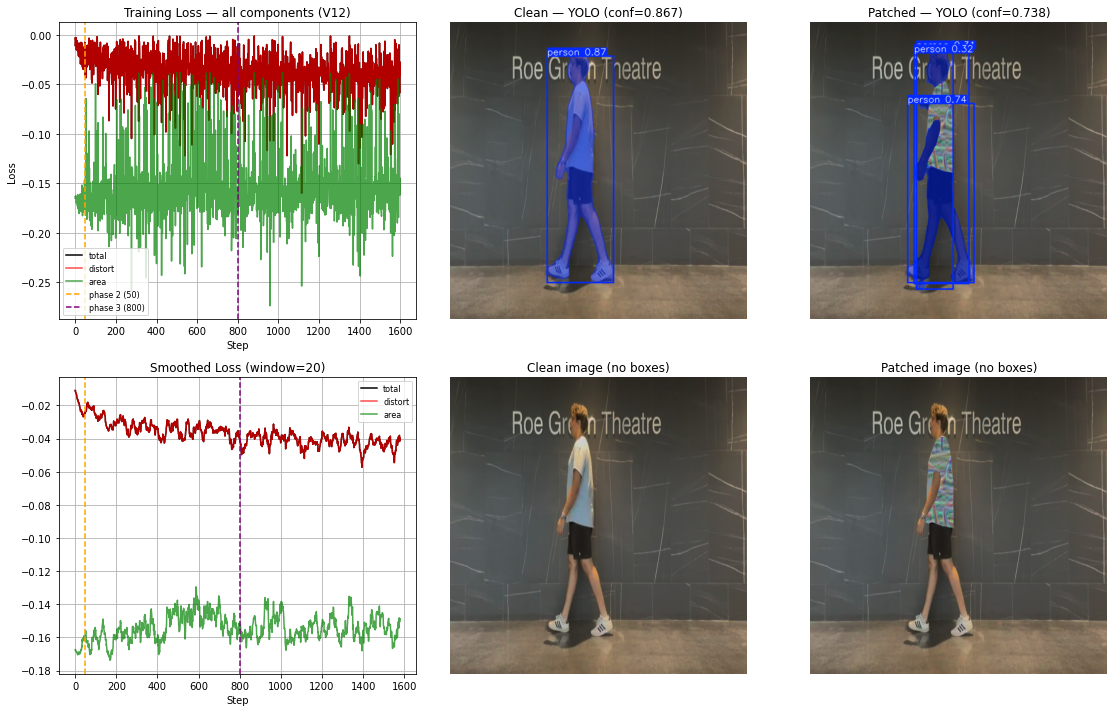

In [17]:
# Cell 13 — Visual evaluation + loss component breakdown
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# Row 1: loss curves
axes[0, 0].plot(loss_history,     label='total',    color='black')
axes[0, 0].plot(distort_history, label='distort', color='red',   alpha=0.7)
axes[0, 0].plot(area_history,     label='area',     color='green', alpha=0.7)
if CURRICULUM_STEPS > 0:
    axes[0, 0].axvline(x=CURRICULUM_STEPS, color='orange', linestyle='--',
                       label=f'phase 2 ({CURRICULUM_STEPS})')
axes[0, 0].axvline(x=800, color='purple', linestyle='--', label='phase 3 (800)')
axes[0, 0].set_title('Training Loss — all components (V12)')
axes[0, 0].set_xlabel('Step')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].legend(fontsize=8)
axes[0, 0].grid(True)

# Row 1: clean detection
axes[0, 1].imshow(cv2.cvtColor(results_clean_eval[0].plot(), cv2.COLOR_BGR2RGB))
axes[0, 1].set_title(f'Clean — YOLO (conf={yolo_clean:.3f})')
axes[0, 1].axis('off')

# Row 1: patched detection
patched_label = f'Patched — YOLO (conf={yolo_patched:.3f})' if yolo_patched else 'Patched — NO DETECTION'
axes[0, 2].imshow(cv2.cvtColor(results_patched_eval[0].plot(), cv2.COLOR_BGR2RGB))
axes[0, 2].set_title(patched_label)
axes[0, 2].axis('off')

# Row 2: smoothed loss (window=20)
window = 20
def smooth(x):
    return np.convolve(x, np.ones(window)/window, mode='valid')

axes[1, 0].plot(smooth(loss_history),     color='black', label='total')
axes[1, 0].plot(smooth(distort_history), color='red',   label='distort', alpha=0.7)
axes[1, 0].plot(smooth(area_history),     color='green', label='area',     alpha=0.7)
if CURRICULUM_STEPS > 0:
    axes[1, 0].axvline(x=CURRICULUM_STEPS, color='orange', linestyle='--')
axes[1, 0].axvline(x=800, color='purple', linestyle='--')
axes[1, 0].set_title(f'Smoothed Loss (window={window})')
axes[1, 0].set_xlabel('Step')
axes[1, 0].legend(fontsize=8)
axes[1, 0].grid(True)

# Row 2: clean image (no overlay)
axes[1, 1].imshow(cv2.cvtColor(img_eval_640, cv2.COLOR_BGR2RGB))
axes[1, 1].set_title('Clean image (no boxes)')
axes[1, 1].axis('off')

# Row 2: patched image (no overlay)
axes[1, 2].imshow(cv2.cvtColor(img_patched_np, cv2.COLOR_BGR2RGB))
axes[1, 2].set_title('Patched image (no boxes)')
axes[1, 2].axis('off')

plt.tight_layout()
plt.show()


In [18]:
patch_np = patch.detach().cpu().squeeze().permute(1, 2, 0).numpy()
patch_np = (patch_np * 255).astype(np.uint8)
patch_bgr = cv2.cvtColor(patch_np, cv2.COLOR_RGB2BGR)

save_path = f"patch.png"
cv2.imwrite(save_path, patch_bgr)
print(f"Patch saved to {save_path}")

Patch saved to patch.png


In [ ]:
import pathlib
from video_segmentation import get_single_mask_from_video, load_segformer_model, write_mask_overlay_video1

TARGET_SIZE = 1024
SHIRT_LABEL = 4
BATCH_SIZE = 8

processor, model, device = load_segformer_model()
print(f"Inference running on {device}")

input_folder = pathlib.Path("../data_processed/test_videos_2")
output_folder = pathlib.Path("../output/test_videos_2")

for input_path in input_folder.iterdir():
    if input_path.is_file():
        file_name = input_path.stem + "_jitter.mp4"
        output_path = output_folder.joinpath(file_name)

        print(f"Processing {input_path}")

        # calculate the mask for the shirt in the video.
        shirt_tensor = get_single_mask_from_video(
            video = str(input_path),
            target_resolution=TARGET_SIZE,
            batch_size=BATCH_SIZE,
            target_label=SHIRT_LABEL,
            processor=processor,
            model=model
        )

        write_mask_overlay_video1(
            input_video=str(input_path),
            output_video=str(output_path),
            mask_tensor=shirt_tensor,
            mode="pattern",
            overlay_img_path="patch.png",
        )



YOLO_MODEL = 'yolov8n-seg'
model = YOLO(YOLO_MODEL)


cap = cv2.VideoCapture("../output/test_videos_2/subset/speed2_Right_jitter.mp4")
fps = cap.get(cv2.CAP_PROP_FPS)
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
 
out = cv2.VideoWriter("../example_out.mp4", cv2.VideoWriter_fourcc(*"avc1"), fps, (width, height))
 
while True:
    ret, frame = cap.read()
    if not ret:
        break
    results = model(frame, verbose=False)
    out.write(results[0].plot())
 
cap.release()
out.release()
print("Done! Saved to example_out.mp4")

Inference running on cuda
Processing ..\data_processed\test_videos_2\subset\speed2_Left.mp4
Processing ..\data_processed\test_videos_2\subset\speed2_Right.mp4
Done! Saved to example_out.mp4
